# ISS Altitude Plotter

This notebook fetches altitude data for the International Space Station (ISS) using the [Where The ISS At? API](https://wheretheiss.at/).  The API’s `satellites/[id]` endpoint returns orbital parameters such as latitude, longitude, and **altitude**【909858184946832†L96-L110】.  The `positions` endpoint can accept up to 10 timestamps and returns a list of position records with altitude and other fields【909858184946832†L125-L169】.  You can read more about the ISS in NASA’s learning resource, which notes that it typically orbits at an average altitude of about **250 miles** (≈400 km)【189668616382783†L341-L343】.

The following cells define a function to fetch ISS altitude data over a specified time range and then plot it using `matplotlib`.  By default, it samples the last 12 hours at 5‑minute intervals, but you can change these parameters.


## Process 01

/Users/Amr/miniconda3/envs/myenv/lib/python3.9/site-packages/spacepy/empiricals.py:26: UserWarning: Qin-Denton/OMNI2 data not found in current format. This module has limited functionality. Run spacepy.toolbox.update(QDomni=True) to download data.
  import spacepy.omni as om


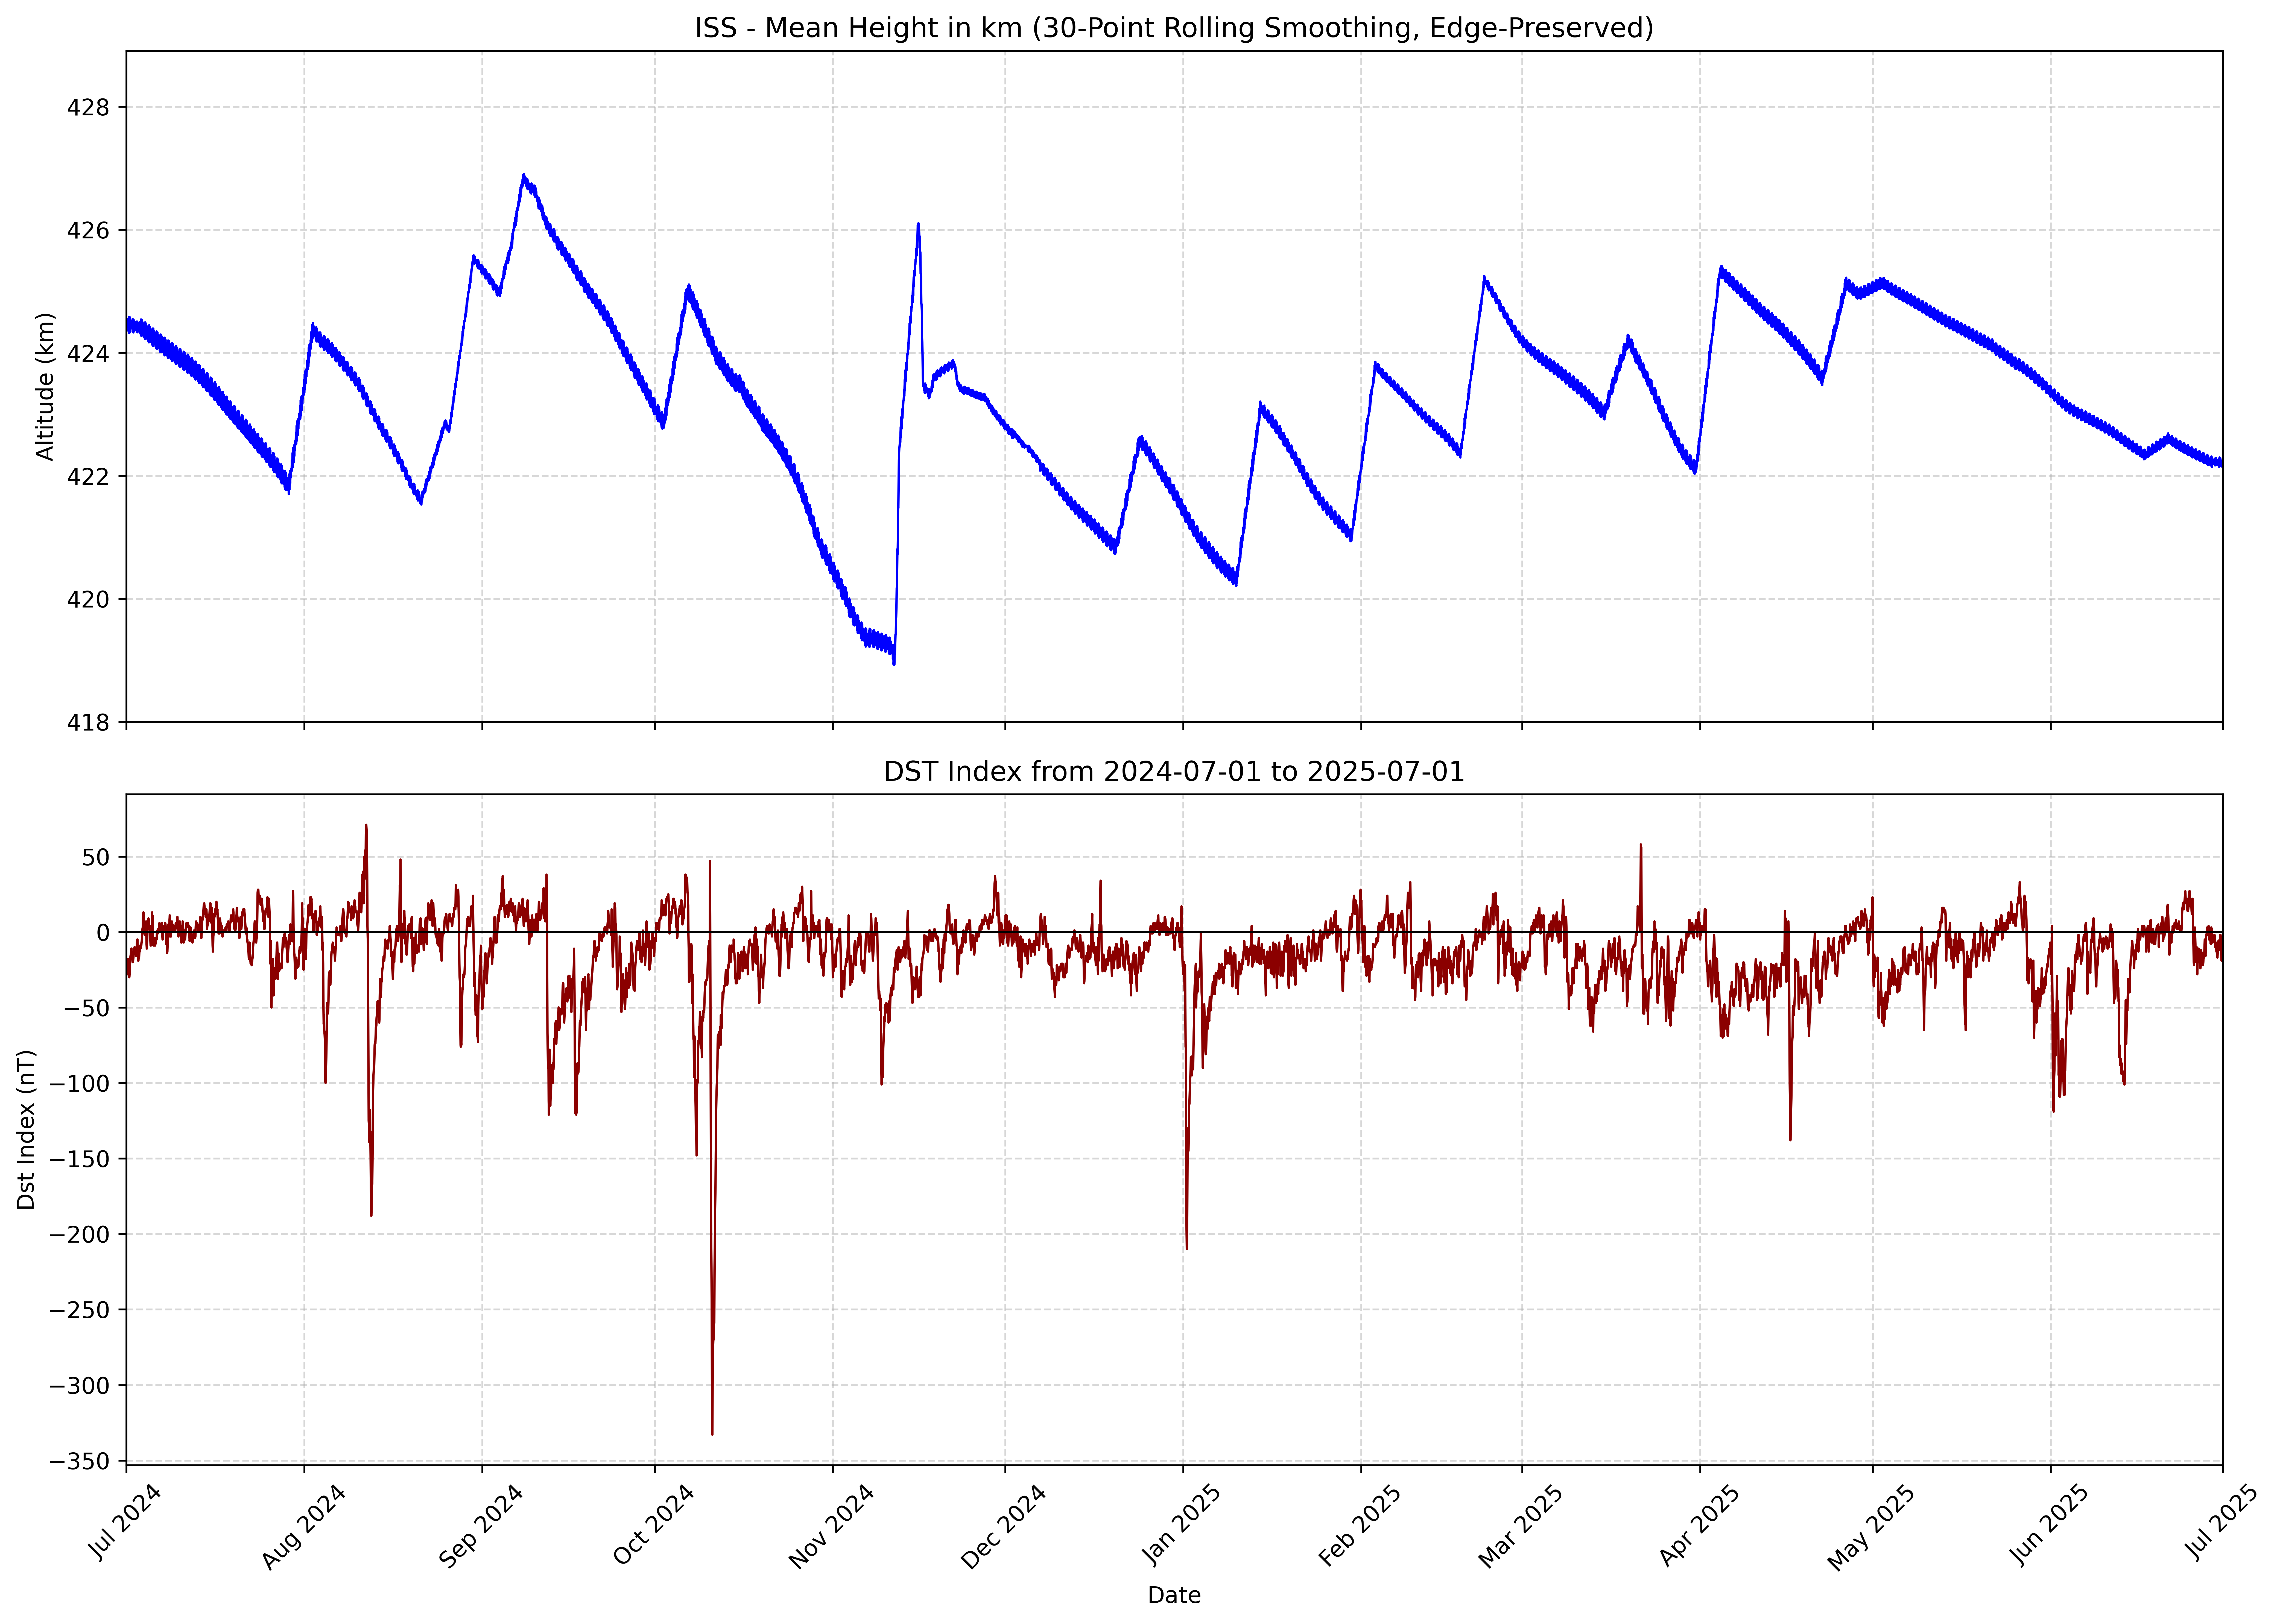

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import spacepy.pybats.kyoto as kyoto

# ============================================================
# 1. Load ISS Altitude Data from the CSV you uploaded
# ============================================================
file_path = "iss_altitude_hourly_jul2024_jul2025.csv"  
df_new = pd.read_csv(file_path)

# Identify the time column (assumes it contains 'time')
time_col = next((c for c in df_new.columns if 'time' in c.lower()), None)
df_new[time_col] = pd.to_datetime(df_new[time_col], errors='coerce')
df_new = df_new.dropna(subset=[time_col]).sort_values(time_col)
df_new.rename(columns={time_col: "time"}, inplace=True)

# Extract altitude and apply edge-preserving smoothing
altitude = df_new["altitude"].values
window = 100
altitude_smooth = pd.Series(altitude).rolling(window=window, center=True, min_periods=1).mean().values

# ============================================================
# 2. Fetch Dst Index Data Using spacepy.kyoto
# ============================================================
tstart = datetime.datetime(2024, 7, 1)
tstop  = datetime.datetime(2025, 7, 1)

# Fetch data from Kyoto WDC
lines = kyoto.dstfetch(tstart.year, tstart.month, tstop.year, tstop.month)
dst_obj = kyoto.KyotoDst(lines)

# Convert to pandas DataFrame
times = pd.to_datetime(dst_obj['time'])
df_dst = pd.DataFrame({'Dst': dst_obj['dst']}, index=times)

# ============================================================
# 3. Create Combined Figure with Two Subplots
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,10), sharex=True, dpi=600)

# --- Subplot 1: ISS Altitude (Smoothed) ---
ax1.plot(df_new["time"], altitude_smooth, color="blue", lw=1)
ax1.set_title("ISS - Mean Height in km (30-Point Rolling Smoothing, Edge-Preserved)")
ax1.set_ylabel("Altitude (km)")
ax1.set_ylim(418, altitude_smooth.max() + 2)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# --- Subplot 2: Dst Index ---
ax2.plot(df_dst.index, df_dst['Dst'], label='Dst Index', color='darkred', lw=1)
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_ylabel("Dst Index (nT)")
ax2.set_xlabel("Date")
ax2.set_title(f"DST Index from {tstart.date()} to {tstop.date()}")
ax2.grid(True, linestyle="--", alpha=0.5)
#ax2.legend()

# Limit x-axis to the data range
x_min = datetime.datetime(2024, 7, 1)
x_max = datetime.datetime(2025, 7, 1)
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


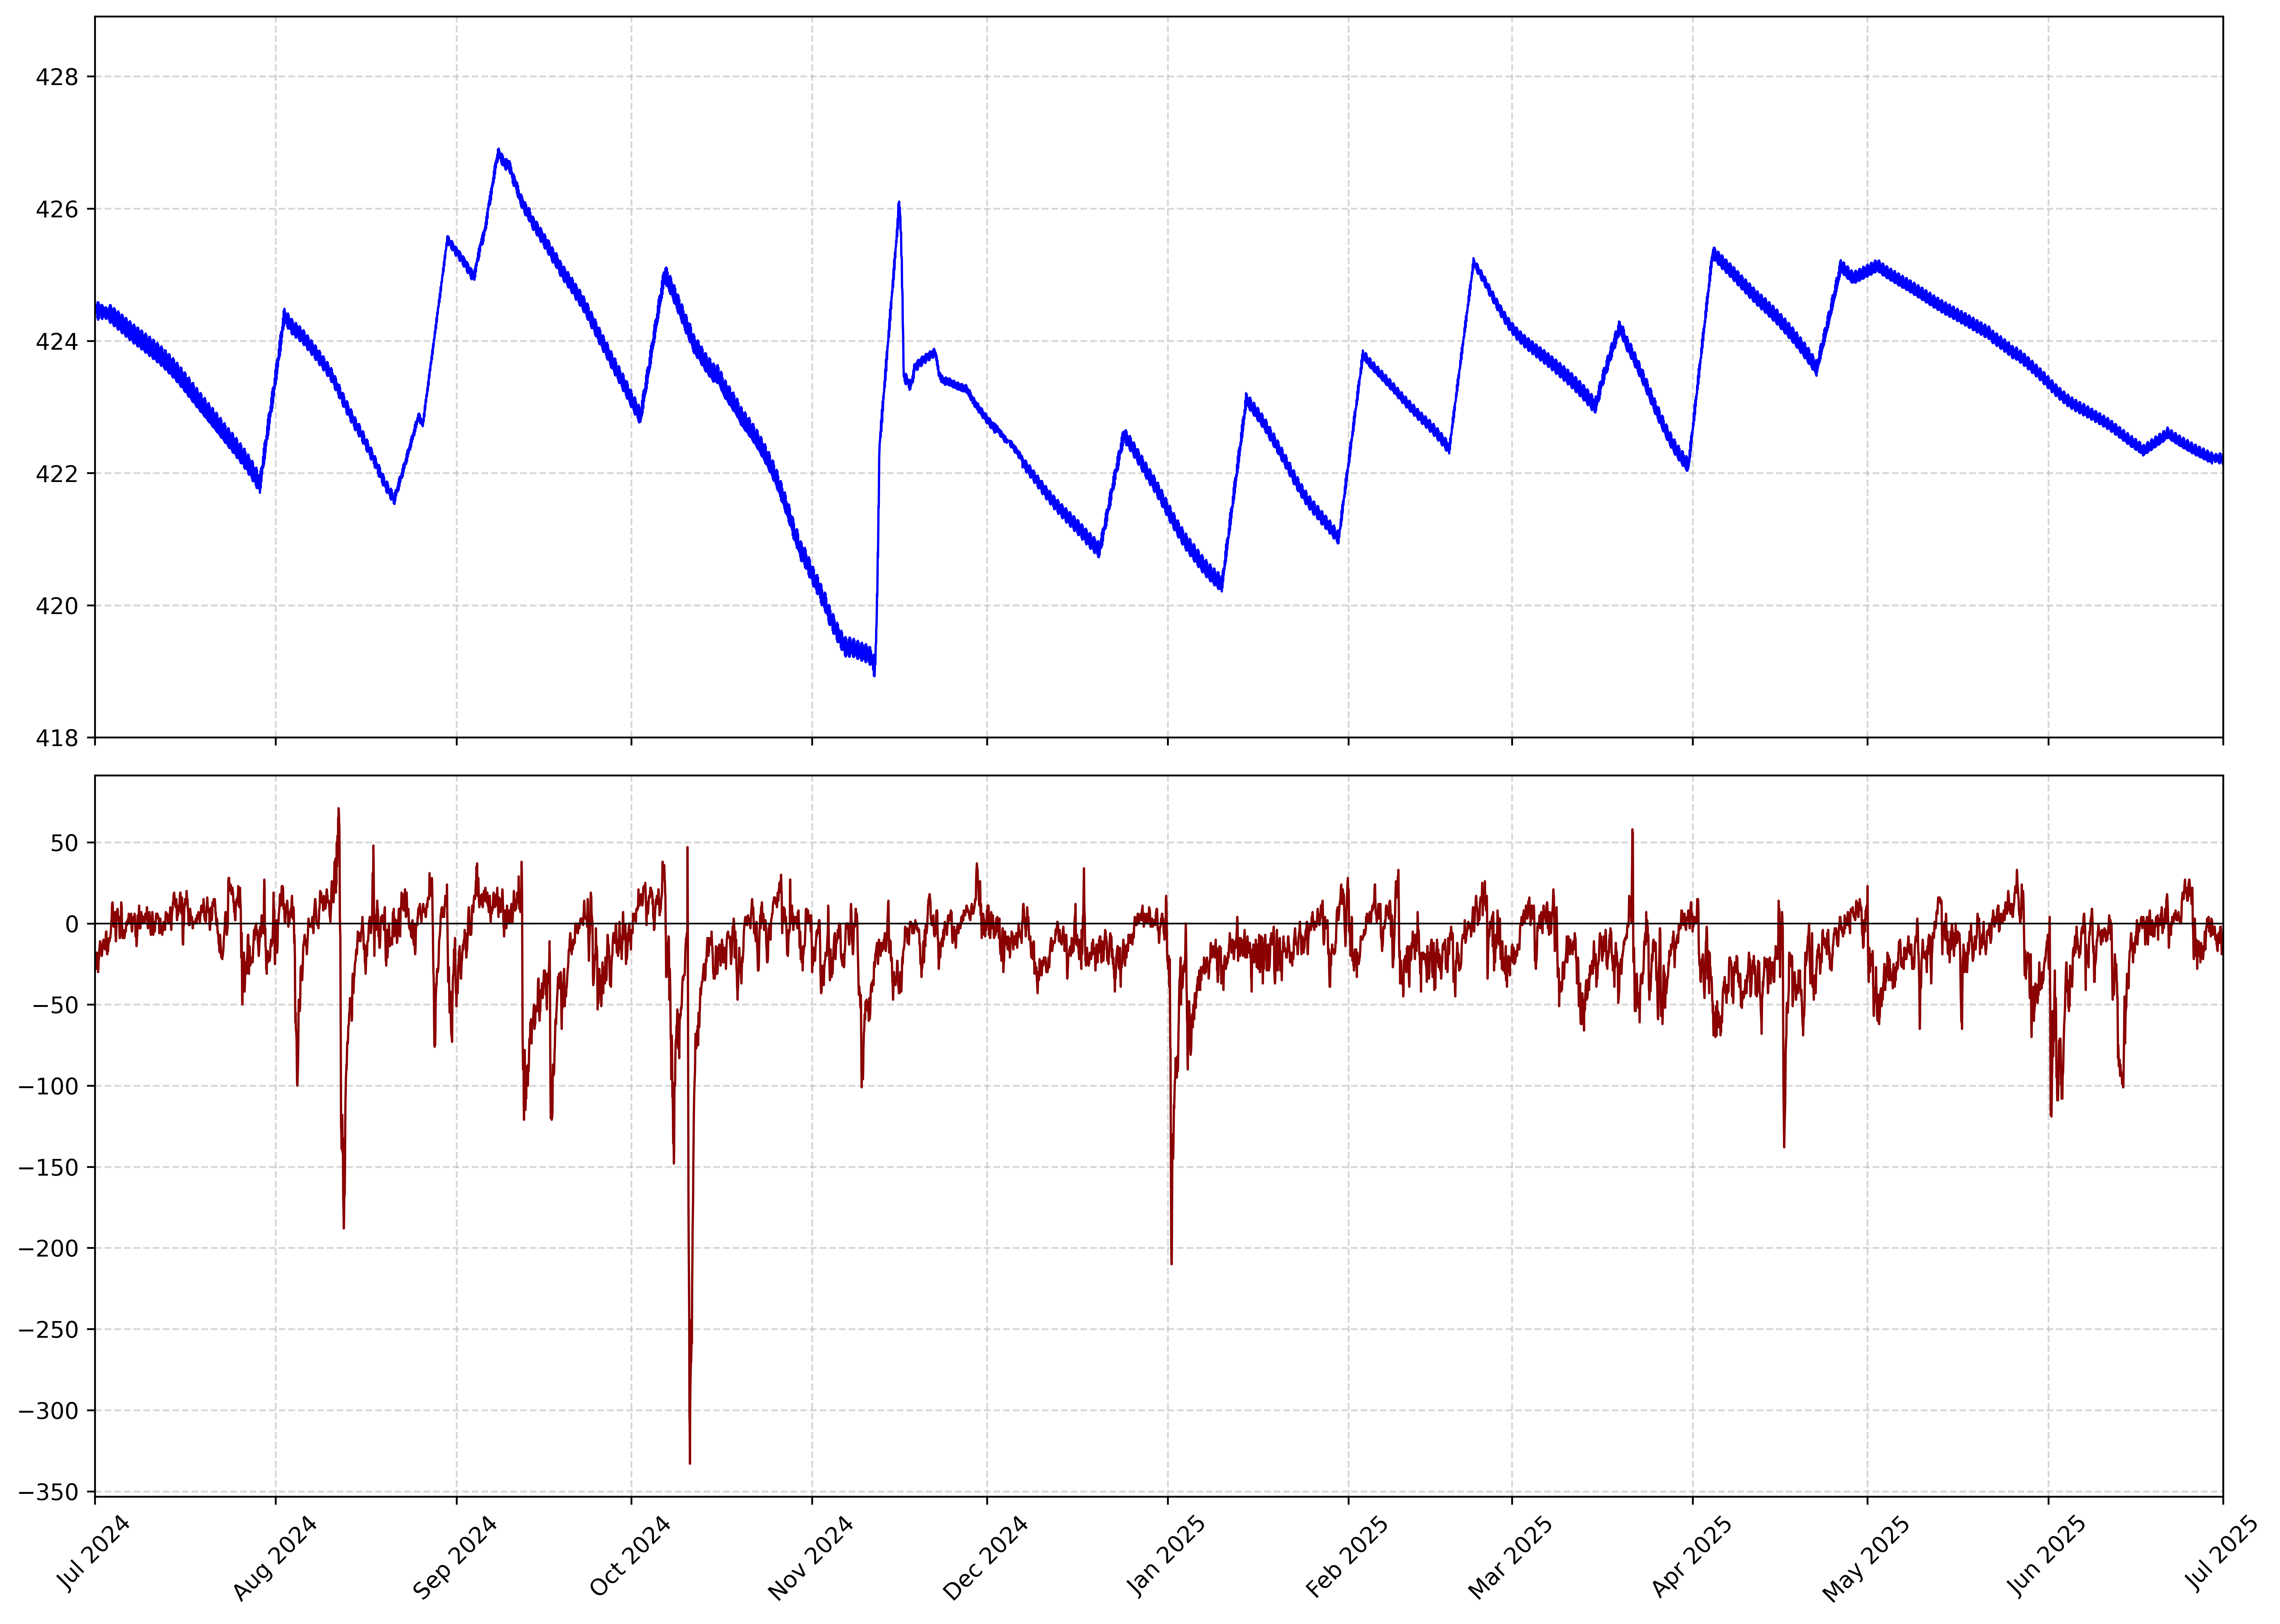

In [2]:
# ============================================================
# 3. Create Combined Figure with Two Subplots
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,10), sharex=True, dpi=600)

# --- Subplot 1: ISS Altitude (Smoothed) ---
ax1.plot(df_new["time"], altitude_smooth, color="blue", lw=1)
#ax1.set_title("ISS - Mean Height in km (30-Point Rolling Smoothing, Edge-Preserved)")
#ax1.set_ylabel("Altitude (km)")
ax1.set_ylim(418, altitude_smooth.max() + 2)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# --- Subplot 2: Dst Index ---
ax2.plot(df_dst.index, df_dst['Dst'], label='Dst Index', color='darkred', lw=1)
ax2.axhline(0, color='black', linewidth=0.7)
#ax2.set_ylabel("Dst Index (nT)")
#ax2.set_xlabel("Date")
#ax2.set_title(f"DST Index from {tstart.date()} to {tstop.date()}")
ax2.grid(True, linestyle="--", alpha=0.5)
#ax2.legend()

# Limit x-axis to the data range
x_min = datetime.datetime(2024, 7, 1)
x_max = datetime.datetime(2025, 7, 1)
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()